# Distributed delay via the linear chain trick

This notebook follows Norma's equation (7),
$$G_a^p(u) = \frac{a^{p+1} u^p}{p!} e^{-au},$$
and solves the distributed-delay problem
$$\dot{x}(t) = \frac{\beta \tanh(\gamma z(t))-x(t)}{\tau}, \qquad z(t) = \int_0^\infty G_a^p(u) x(t-u)\,du,$$
with constant prehistory $x(t)=x_0$ for $t \le 0$. For this kernel, the delay term is exactly reproduced by the linear chain
$$\dot{y}_0 = a(x-y_0), \qquad \dot{y}_j = a(y_{j-1}-y_j), \quad j=1,\dots,p,$$
so that $z(t)=y_p(t)$. The resulting ODE system is integrated with `scipy.integrate.solve_ivp`.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
from scipy.integrate import solve_ivp
from scipy.special import gammaincc

In [ ]:
def gamma_kernel(u, a, p):
    u = np.asarray(u)
    return (a ** (p + 1) / factorial(p)) * (u ** p) * np.exp(-a * u)


def delayed_rhs(t, state, tau, beta, gamma, a):
    del t
    x = state[0]
    chain = state[1:]
    z = chain[-1]

    dx = (beta * np.tanh(gamma * z) - x) / tau

    dchain = np.empty_like(chain)
    dchain[0] = a * (x - chain[0])
    dchain[1:] = a * (chain[:-1] - chain[1:])

    return np.concatenate(([dx], dchain))


def solve_linear_chain(tau, beta, gamma, mean_delay, p, x_history, t_eval):
    a = (p + 1) / mean_delay
    initial_state = np.full(p + 2, x_history, dtype=float)

    sol = solve_ivp(
        delayed_rhs,
        (t_eval[0], t_eval[-1]),
        initial_state,
        t_eval=t_eval,
        args=(tau, beta, gamma, a),
        rtol=1e-8,
        atol=1e-10,
    )
    if not sol.success:
        raise RuntimeError(sol.message)

    x = sol.y[0]
    z = sol.y[-1]
    return a, x, z, sol

def convolution_reference(x, t_eval, x_history, a, p):
    dt = t_eval[1] - t_eval[0]
    kernel = gamma_kernel(t_eval, a, p)
    causal_part = dt * np.convolve(x, kernel, mode='full')[: len(t_eval)]
    history_tail = x_history * gammaincc(p + 1, a * t_eval)
    return causal_part + history_tail

In [7]:
tau = 0.9
beta = -2.1
gamma = 1.0
mean_delay = 4.0
p = 3
x_history = 0.2

t_eval = np.linspace(0.0, 100.0, 8001)
a, x, z_chain, sol = solve_linear_chain(tau, beta, gamma, mean_delay, p, x_history, t_eval)
z_ref = convolution_reference(x, t_eval, x_history, a, p)
max_error = np.max(np.abs(z_chain - z_ref))

print(f'order p = {p}')
print(f'tau = {tau:.3f}')
print(f'beta = {beta:.3f}')
print(f'gamma = {gamma:.3f}')
print(f'a = {a:.3f}')
print(f'mean delay = {(p + 1) / a:.3f}')
print(f'max |z_chain - z_ref| = {max_error:.3e}')

order p = 3
tau = 0.900
beta = -2.100
gamma = 1.000
a = 1.000
mean delay = 4.000
max |z_chain - z_ref| = 2.820e-04


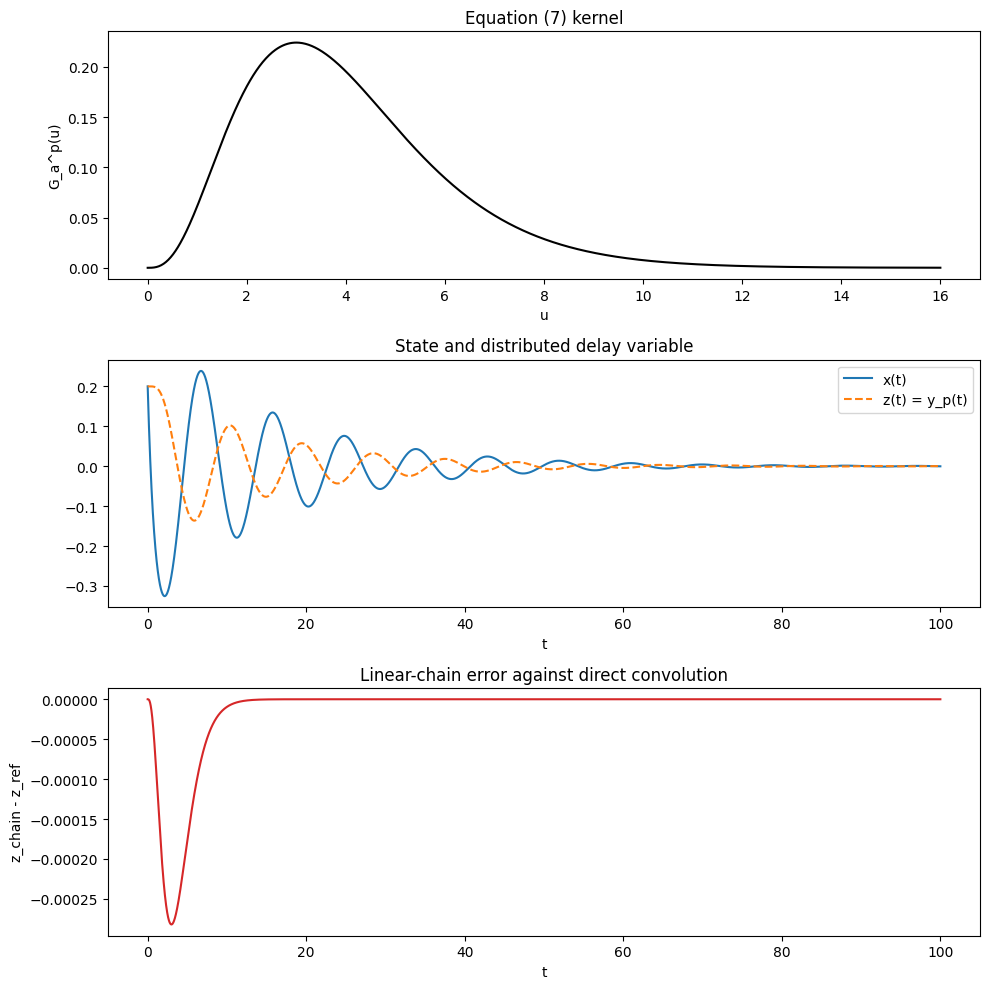

In [8]:
u = np.linspace(0.0, 4.0 * mean_delay, 1000)
kernel = gamma_kernel(u, a, p)

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=False)

axes[0].plot(u, kernel, color='black')
axes[0].set_title('Equation (7) kernel')
axes[0].set_xlabel('u')
axes[0].set_ylabel('G_a^p(u)')

axes[1].plot(t_eval, x, label='x(t)')
axes[1].plot(t_eval, z_chain, '--', label='z(t) = y_p(t)')
axes[1].set_title('State and distributed delay variable')
axes[1].set_xlabel('t')
axes[1].legend()

axes[2].plot(t_eval, z_chain - z_ref, color='tab:red')
axes[2].set_title('Linear-chain error against direct convolution')
axes[2].set_xlabel('t')
axes[2].set_ylabel('z_chain - z_ref')

plt.tight_layout()
plt.show()

from IPython.display import Audio
Audio(x, rate=8000)